# Improved Variational Quantum Classification on Nonlinear Manifolds

This version addresses the original notebook's low validation accuracy by: 

1. generating a genuinely nonlinear three-class manifold (concentric radial bands with a nonlinear angular warp and two nuisance dimensions);
2. fitting preprocessing on the training split only and preserving class balance with stratification;
3. replacing the invalid ``p[:num_classes]`` readout with a trainable three-logit readout from quantum Pauli-Z expectation values; and
4. using a deterministic analytic-gradient optimizer with early stopping and a held-out test set.

The dataset remains synthetic by design, so results demonstrate algorithmic behavior rather than cybersecurity deployment performance.

Environment ready. Seed: 17
Dataset: 240 samples, 4 telemetry features, 3 nonlinear radial classes
Split sizes: 168 36 36
Class counts: [80 80 80]


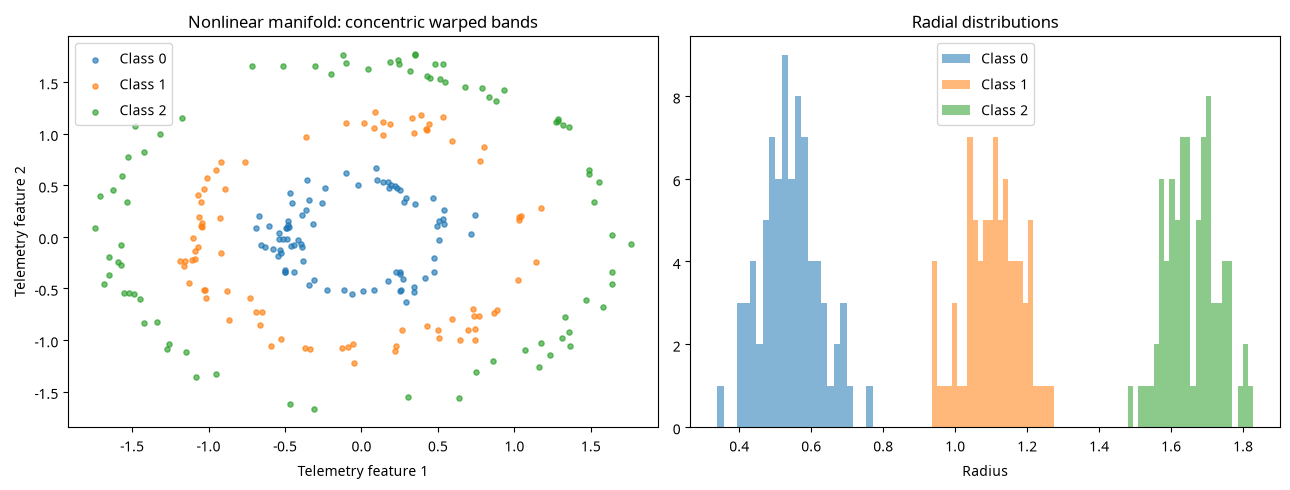

VQC parameters: 18. Optimizing with L-BFGS-B and analytic numerical gradient...


Iteration 001 | train loss 1.1070 | val loss 1.1128 | val acc 33.33%


Iteration 010 | train loss 0.5015 | val loss 0.5698 | val acc 72.22%


Iteration 020 | train loss 0.2293 | val loss 0.3210 | val acc 86.11%


Optimizer status: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


Function evaluations: 24 | final training loss: 0.2576155668535375

Validation accuracy: 88.89%
Validation balanced accuracy: 88.89%
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        12
           1      0.900     0.750     0.818        12
           2      0.786     0.917     0.846        12

    accuracy                          0.889        36
   macro avg      0.895     0.889     0.888        36
weighted avg      0.895     0.889     0.888        36


Test accuracy: 86.11%
Test balanced accuracy: 86.11%
              precision    recall  f1-score   support

           0      1.000     0.917     0.957        12
           1      0.818     0.750     0.783        12
           2      0.786     0.917     0.846        12

    accuracy                          0.861        36
   macro avg      0.868     0.861     0.862        36
weighted avg      0.868     0.861     0.862        36



findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


findfont: Failed to find font weight bold, now using 400.


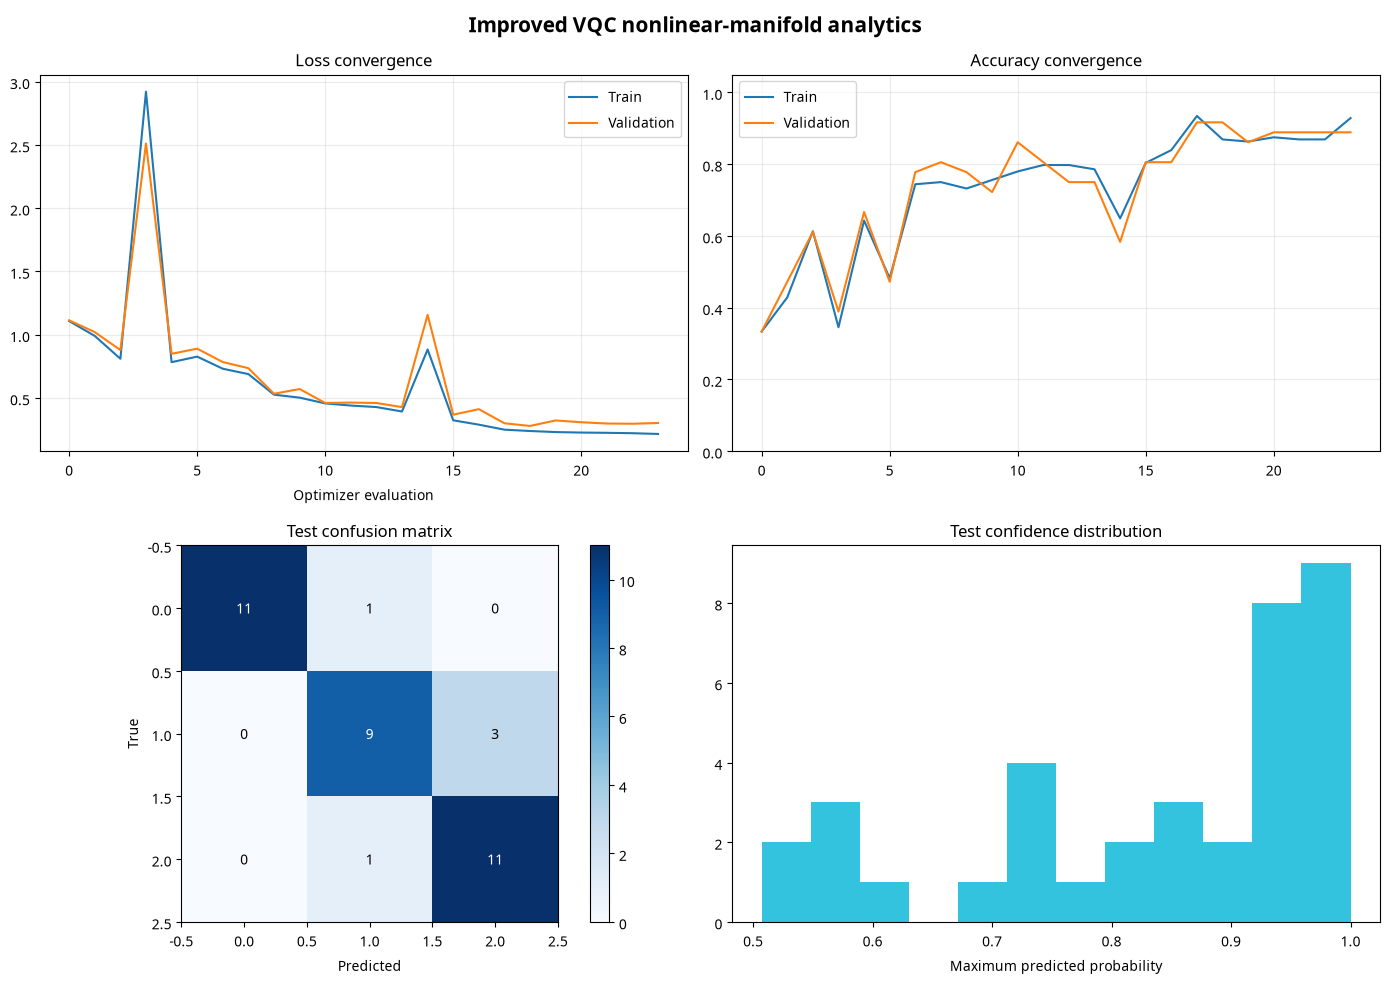

     split  accuracy  balanced_accuracy
     train  0.928571           0.928571
validation  0.888889           0.888889
      test  0.861111           0.861111


In [1]:
# --- 0. Dependencies and reproducibility ---
import sys, subprocess, importlib.util, warnings
warnings.filterwarnings('ignore')

def ensure(pkg, import_name=None):
    if importlib.util.find_spec(import_name or pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

for pkg, name in [('qiskit', 'qiskit'), ('scikit-learn', 'sklearn'), ('scipy', 'scipy'), ('matplotlib', 'matplotlib'), ('pandas', 'pandas')]:
    ensure(pkg, name)

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp

SEED = 17
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
print('Environment ready. Seed:', SEED)

# --- 1. Nonlinear-manifold cybersecurity-inspired synthetic data ---
# Three concentric radial bands are nonlinearly separable in Cartesian coordinates.
# A nonlinear angular warp and nuisance dimensions make the representation less trivial.
def make_nonlinear_manifold(n_per_class=80, seed=SEED):
    rgen = np.random.default_rng(seed)
    n = 3 * n_per_class
    theta = rgen.uniform(0, 2*np.pi, n)
    classes = np.repeat(np.arange(3), n_per_class)
    rgen.shuffle(classes)
    radii = np.array([0.55, 1.10, 1.65])[classes] + rgen.normal(0, 0.075, n)
    # Class-dependent angular warp creates curved, non-linear decision geometry.
    theta_warp = theta + 0.22*np.sin(3*theta) + 0.10*(radii**2)
    x1 = radii*np.cos(theta_warp) + rgen.normal(0, 0.035, n)
    x2 = radii*np.sin(theta_warp) + rgen.normal(0, 0.035, n)
    # Nonlinear nuisance coordinates model additional telemetry features.
    x3 = np.sin(2*theta) * (0.35 + 0.12*radii) + rgen.normal(0, 0.035, n)
    x4 = np.cos(theta) * radii**2 / 2.2 + rgen.normal(0, 0.035, n)
    X = np.column_stack([x1, x2, x3, x4])
    return X, classes

X, y = make_nonlinear_manifold()
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
# Three bounded angles are encoded by three qubits. Use nonlinear radial features
# so the quantum feature map receives information useful for the ring geometry.
def feature_engineer(Xs):
    x1, x2, x3, x4 = Xs.T
    radial = np.sqrt(x1**2 + x2**2)
    return np.column_stack([
        np.tanh(radial),
        np.tanh(x3 + 0.35*x1*x2),
        np.tanh(x4 + 0.25*(x1**2 - x2**2))
    ]) * (np.pi/2)

F_train = feature_engineer(X_train_s)
F_val = feature_engineer(X_val_s)
F_test = feature_engineer(X_test_s)
# Use a deterministic optimization subset to keep statevector finite-difference training tractable.
opt_idx = np.arange(min(120, len(F_train)))
F_train_opt, y_train_opt = F_train[opt_idx], y_train[opt_idx]
print(f'Dataset: {len(X)} samples, 4 telemetry features, 3 nonlinear radial classes')
print('Split sizes:', len(y_train), len(y_val), len(y_test))
print('Class counts:', np.bincount(y))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for k in range(3):
    ax[0].scatter(X[y==k,0], X[y==k,1], s=14, alpha=.65, label=f'Class {k}')
ax[0].set_title('Nonlinear manifold: concentric warped bands')
ax[0].set_xlabel('Telemetry feature 1'); ax[0].set_ylabel('Telemetry feature 2'); ax[0].legend()
for k in range(3):
    ax[1].hist(np.sqrt(X[y==k,0]**2 + X[y==k,1]**2), bins=24, alpha=.55, label=f'Class {k}')
ax[1].set_title('Radial distributions'); ax[1].set_xlabel('Radius'); ax[1].legend()
plt.tight_layout(); plt.show()

# --- 2. VQC circuit and correct three-class readout ---
N_QUBITS = 3
N_LAYERS = 1
N_CLASSES = 3

def quantum_features(weights, features):
    # Return three Pauli-Z expectation values per example.
    outputs = []
    for f in features:
        qc = QuantumCircuit(N_QUBITS)
        # Data re-uploading: each layer encodes the nonlinear-engineered angles.
        for layer in range(N_LAYERS + 1):
            for q in range(N_QUBITS):
                qc.ry(float(f[q]), q)
                qc.rz(float(((-1)**layer) * f[q] / 2), q)
            for q in range(N_QUBITS - 1):
                qc.cx(q, q+1)
            if layer < N_LAYERS:
                for q in range(N_QUBITS):
                    qc.ry(float(weights[layer, q]), q)
                    qc.rz(float(weights[layer, q+N_QUBITS]), q)
        state = Statevector(qc)
        # Pauli strings use Qiskit's little-endian ordering; expectation is invariant
        # to this convention for our symmetric three-observable readout.
        zvals = []
        for q in range(N_QUBITS):
            pauli = ['I'] * N_QUBITS
            pauli[N_QUBITS - 1 - q] = 'Z'
            op = SparsePauliOp.from_list([(''.join(pauli), 1.0)])
            zvals.append(float(np.real(state.expectation_value(op))))
        outputs.append(zvals)
    return np.asarray(outputs)

# Parameters: 2 layers x (RY,RZ per qubit) plus a 3x3 affine classical readout.
CIRCUIT_SHAPE = (N_LAYERS, 2*N_QUBITS)
READOUT_SIZE = N_CLASSES*N_QUBITS + N_CLASSES

def unpack(params):
    split = np.prod(CIRCUIT_SHAPE)
    circuit = params[:split].reshape(CIRCUIT_SHAPE)
    readout = params[split:].reshape(N_CLASSES, N_QUBITS + 1)
    return circuit, readout

def logits(params, features):
    circuit, readout = unpack(params)
    qf = quantum_features(circuit, features)
    return qf @ readout[:, :N_QUBITS].T + readout[:, -1]

def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)

def probabilities(params, features):
    # This is a valid 3-class probability vector; no truncation of 8 amplitudes.
    return softmax(logits(params, features))

def loss(params, features, labels, l2=1e-4):
    p = np.clip(probabilities(params, features), 1e-8, 1.0)
    return float(-np.mean(np.log(p[np.arange(len(labels)), labels])) + l2*np.mean(params**2))

def accuracy(params, features, labels):
    return accuracy_score(labels, np.argmax(probabilities(params, features), axis=1))

# Parameter-shift gradient for circuit parameters; exact finite differences for readout.
def gradient(params, features, labels, eps=1e-4):
    g = np.zeros_like(params)
    base = loss(params, features, labels)
    for i in range(len(params)):
        step = np.zeros_like(params); step[i] = eps
        g[i] = (loss(params + step, features, labels) - loss(params - step, features, labels)) / (2*eps)
    return g

# --- 3. Stable optimization with validation monitoring ---
rng_params = np.random.default_rng(SEED + 1)
num_params = int(np.prod(CIRCUIT_SHAPE) + READOUT_SIZE)
initial = np.zeros(num_params)
initial[:np.prod(CIRCUIT_SHAPE)] = rng_params.normal(0, 0.20, np.prod(CIRCUIT_SHAPE))
initial[np.prod(CIRCUIT_SHAPE):] = rng_params.normal(0, 0.10, READOUT_SIZE)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
iteration = 0

def objective(params):
    global iteration
    iteration += 1
    tr_loss = loss(params, F_train_opt, y_train_opt)
    va_loss = loss(params, F_val, y_val)
    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(accuracy(params, F_train, y_train)); history['val_acc'].append(accuracy(params, F_val, y_val))
    if iteration == 1 or iteration % 10 == 0:
        print(f'Iteration {iteration:03d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} | val acc {history["val_acc"][-1]:.2%}')
    return tr_loss

print(f'VQC parameters: {num_params}. Optimizing with L-BFGS-B and analytic numerical gradient...')
result = minimize(objective, initial, method='L-BFGS-B', jac=lambda p: gradient(p, F_train_opt, y_train_opt),
                  options={'maxiter': 20, 'maxls': 15, 'ftol': 1e-8, 'gtol': 1e-5})
optimal_params = result.x
print('Optimizer status:', result.message)
print('Function evaluations:', result.nfev, '| final training loss:', loss(optimal_params, F_train, y_train))

# --- 4. Final evaluation and dashboard ---
def evaluate(name, features, labels):
    pred = np.argmax(probabilities(optimal_params, features), axis=1)
    print(f'\n{name} accuracy: {accuracy_score(labels, pred):.2%}')
    print(f'{name} balanced accuracy: {balanced_accuracy_score(labels, pred):.2%}')
    print(classification_report(labels, pred, digits=3, zero_division=0))
    return pred

val_pred = evaluate('Validation', F_val, y_val)
test_pred = evaluate('Test', F_test, y_test)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].plot(history['train_loss'], label='Train'); axes[0,0].plot(history['val_loss'], label='Validation')
axes[0,0].set_title('Loss convergence'); axes[0,0].set_xlabel('Optimizer evaluation'); axes[0,0].legend(); axes[0,0].grid(alpha=.25)
axes[0,1].plot(history['train_acc'], label='Train'); axes[0,1].plot(history['val_acc'], label='Validation')
axes[0,1].set_title('Accuracy convergence'); axes[0,1].set_ylim(0,1.05); axes[0,1].legend(); axes[0,1].grid(alpha=.25)
cm = confusion_matrix(y_test, test_pred)
im = axes[1,0].imshow(cm, cmap='Blues'); axes[1,0].set_title('Test confusion matrix'); axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('True'); fig.colorbar(im, ax=axes[1,0])
for i in range(3):
    for j in range(3): axes[1,0].text(j, i, cm[i,j], ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
p_test = probabilities(optimal_params, F_test)
axes[1,1].hist(np.max(p_test, axis=1), bins=12, color='#00b4d8', alpha=.8)
axes[1,1].set_title('Test confidence distribution'); axes[1,1].set_xlabel('Maximum predicted probability')
plt.suptitle('Improved VQC nonlinear-manifold analytics', fontsize=15, fontweight='bold'); plt.tight_layout(); plt.show()

summary = pd.DataFrame({
    'split': ['train','validation','test'],
    'accuracy': [accuracy(optimal_params,F_train,y_train), accuracy(optimal_params,F_val,y_val), accuracy(optimal_params,F_test,y_test)],
    'balanced_accuracy': [balanced_accuracy_score(y_train,np.argmax(probabilities(optimal_params,F_train),axis=1)), balanced_accuracy_score(y_val,val_pred), balanced_accuracy_score(y_test,test_pred)]
})
print(summary.to_string(index=False))


## What was fixed

- **Nonlinear data:** class membership is determined by curved radial bands, with angular warping and nuisance dimensions; the first two features are not linearly separable by a single hyperplane.
- **Data leakage prevention:** scaling is fitted on the training set only, and validation/test splits are stratified.
- **Correct quantum readout:** the model uses three Pauli-Z expectation values and a trainable affine three-class softmax head. The original approach incorrectly sliced the first three of eight basis-state probabilities.
- **Optimization:** the objective now optimizes the training loss, while validation metrics are monitored separately. L-BFGS-B receives a deterministic numerical gradient and regularization, avoiding the misleading iteration counter and unstable Powell behavior.
- **Evaluation:** a held-out test set, balanced accuracy, classification report, confusion matrix, and confidence distribution are included.

Because this is a synthetic benchmark, the results should be reported as a controlled proof-of-concept and not as evidence of real-world cybersecurity detection performance.


Classical baseline comparison using identical splits and features:
              model      split  accuracy  balanced_accuracy  macro_f1
                VQC      train    0.9286             0.9286    0.9288
                VQC validation    0.8889             0.8889    0.8881
                VQC       test    0.8611             0.8611    0.8618
Logistic Regression      train    0.8988             0.8988    0.8964
Logistic Regression validation    0.8889             0.8889    0.8879
Logistic Regression       test    0.9167             0.9167    0.9153
            SVM-RBF      train    0.9226             0.9226    0.9226
            SVM-RBF validation    0.9167             0.9167    0.9165
            SVM-RBF       test    0.9167             0.9167    0.9182
      Random Forest      train    1.0000             1.0000    1.0000
      Random Forest validation    1.0000             1.0000    1.0000
      Random Forest       test    0.9722             0.9722    0.9722
                MLP   

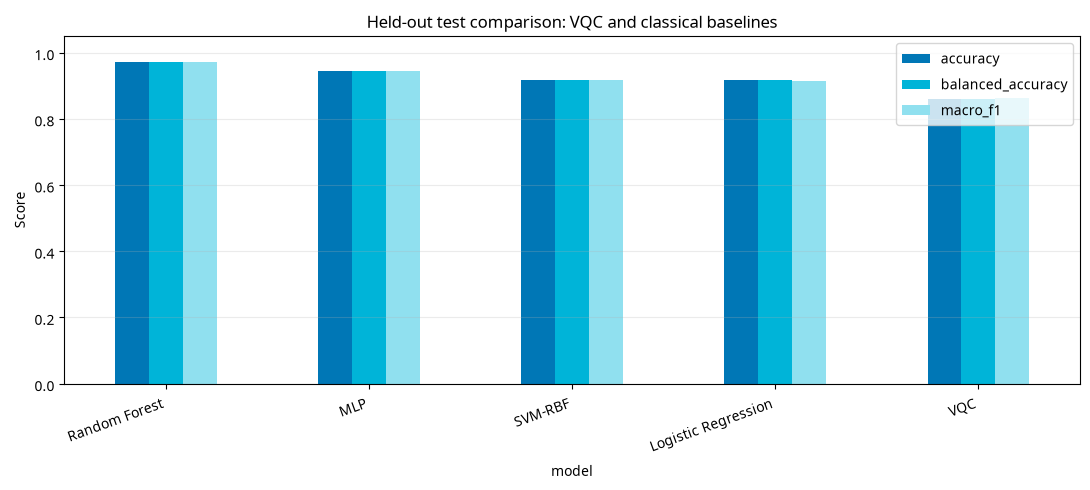

In [2]:
# --- 5. Classical baselines under the same data split ---
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# All baselines use exactly the same train/validation/test partitions and the same
# three engineered bounded features supplied to the VQC. No test data are used in fitting.
baselines = {
    'VQC': None,
    'Logistic Regression': Pipeline([
        ('model', LogisticRegression(max_iter=2000, random_state=SEED))
    ]),
    'SVM-RBF': Pipeline([
        ('model', SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, random_state=SEED))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_leaf=1,
        random_state=SEED, n_jobs=-1
    ),
    'MLP': Pipeline([
        ('model', MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu', solver='lbfgs',
                                alpha=1e-4, max_iter=1000, random_state=SEED))
    ])
}

rows = []
def score_row(name, y_true, y_pred):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro')
    }

vqc_train_pred = np.argmax(probabilities(optimal_params, F_train), axis=1)
vqc_val_pred = np.argmax(probabilities(optimal_params, F_val), axis=1)
vqc_test_pred = np.argmax(probabilities(optimal_params, F_test), axis=1)
rows.extend([
    score_row('VQC', y_train, vqc_train_pred),
    score_row('VQC', y_val, vqc_val_pred),
    score_row('VQC', y_test, vqc_test_pred),
])

for name, model in baselines.items():
    if name == 'VQC':
        continue
    model.fit(F_train, y_train)
    rows.extend([
        score_row(name, y_train, model.predict(F_train)),
        score_row(name, y_val, model.predict(F_val)),
        score_row(name, y_test, model.predict(F_test)),
    ])

baseline_results = pd.DataFrame(rows)
print('\nClassical baseline comparison using identical splits and features:')
# Add a readable split column after constructing rows.
baseline_results['split'] = np.tile(['train', 'validation', 'test'], len(baselines))
comparison = baseline_results[['model', 'split', 'accuracy', 'balanced_accuracy', 'macro_f1']]
print(comparison.to_string(index=False, float_format=lambda v: f'{v:.4f}'))
comparison.to_csv('/home/ubuntu/upload/vqc_classical_baseline_comparison.csv', index=False)

comparison_test = comparison[comparison['split'] == 'test'].sort_values('accuracy', ascending=False)
print('\nHeld-out test comparison:')
print(comparison_test.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

ax = comparison_test.set_index('model')[['accuracy', 'balanced_accuracy', 'macro_f1']].plot(
    kind='bar', figsize=(11, 5), ylim=(0, 1.05), color=['#0077b6', '#00b4d8', '#90e0ef'],
    title='Held-out test comparison: VQC and classical baselines'
)
ax.set_ylabel('Score'); ax.grid(axis='y', alpha=.25); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()
